In [18]:
import pandas as pd
from pathlib import Path
# TASK 3 - SALARYINSIGHT
# Missing Value Analysis & Imputation
df = pd.read_csv("salary_task1_cleaned.csv")
# 2. Basic Dataset Information
print("Missing Value Analysis")
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)


# 3. Missing Value Count

missing_count = df.isnull().sum()
print(missing_count)


# 4. Missing Value Percentage


missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage.round(2)
})

# Only display columns having missing values
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    by="Missing_Count",
    ascending=False
)
print(missing_summary)
# 5. Total Missing Values
total_missing = df.isnull().sum().sum()

print("\nTotal Missing Values:", total_missing)



# 6. Duplicate Rows

duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)


# 7. Numerical Columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)


# 8. Categorical Columns
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

Missing Value Analysis

Dataset Shape:
(2000, 18)

Column Names:
['age', 'gender', 'education', 'experience_years', 'role_seniority', 'company_size', 'location_tier', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'salary_bdt', 'recent_project_description_length', 'survey_date', 'recent_note', 'survey_year', 'survey_month', 'role_seniority_encoded']

Data Types:
age                                    int64
gender                                   str
education                                str
experience_years                     float64
role_seniority                           str
company_size                             str
location_tier                            str
skills_count                         float64
certifications                       float64
worked_remote                          int64
last_promotion_years_ago             float64
salary_bdt                             int64
recent_project_description_length    float64
survey_date       

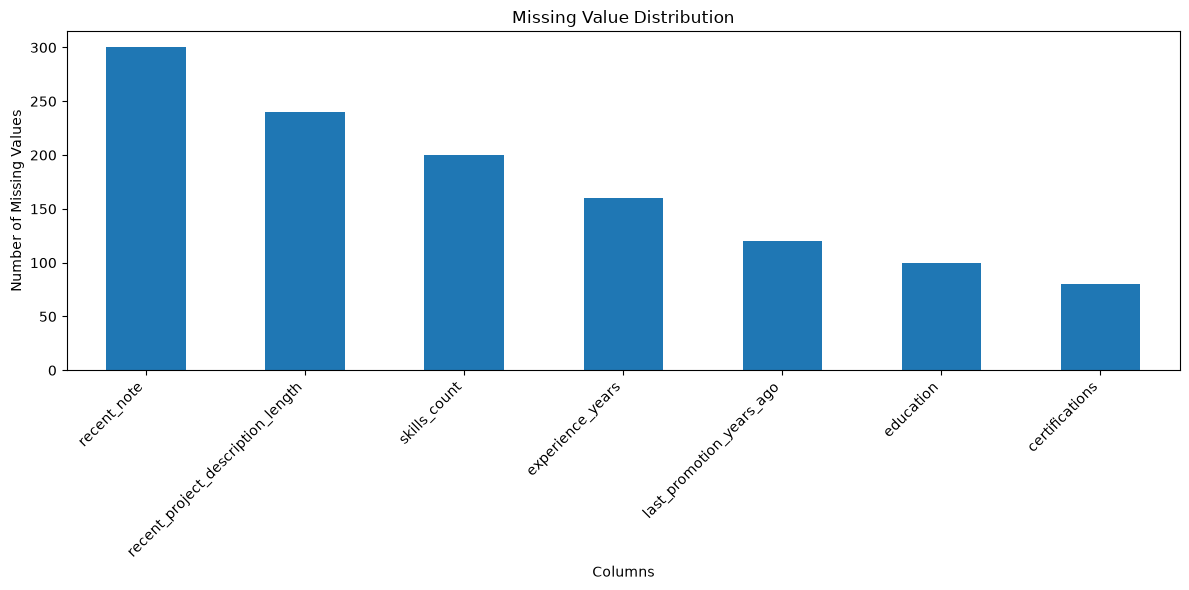

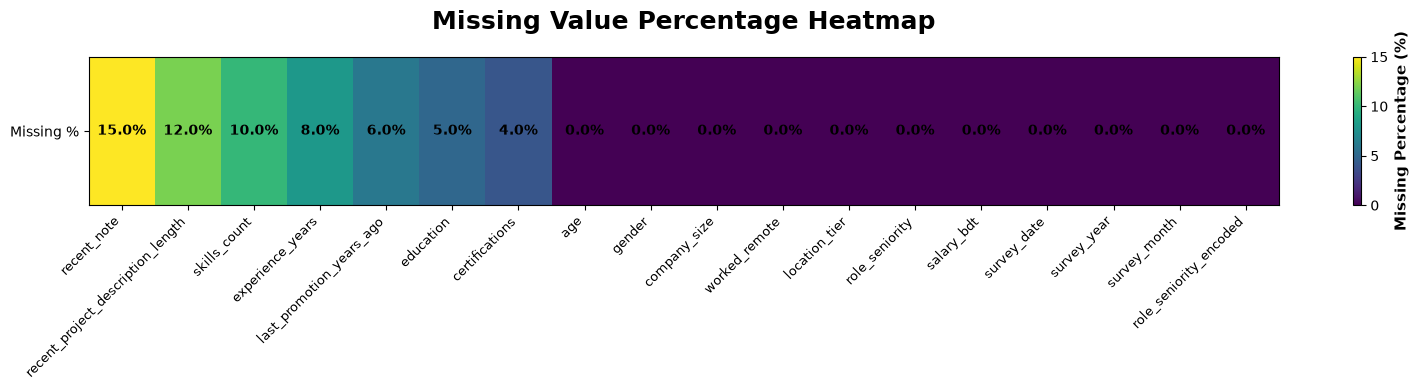

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
missing_data = df.isnull().sum()


# Keep only columns having missing values
missing_data = missing_data[missing_data > 0].sort_values(
    ascending=False
)
plt.figure(figsize=(12, 6))
missing_data.plot(
    kind="bar"
)
plt.title("Missing Value Distribution")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Calculate missing percentage for every column
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

# Convert into a 2D DataFrame for heatmap
heatmap_data = pd.DataFrame(
    [missing_percentage.values],
    columns=missing_percentage.index
)

plt.figure(figsize=(16, 4))

# Plot percentage heatmap
plt.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Title
plt.title(
    "Missing Value Percentage Heatmap",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# X-axis
plt.xticks(
    ticks=range(len(missing_percentage)),
    labels=missing_percentage.index,
    rotation=45,
    ha="right",
    fontsize=9
)

# Remove Y-axis because there is only one percentage row
plt.yticks(
    [0],
    ["Missing %"],
    fontsize=10
)

# Add percentage values inside heatmap
for i, value in enumerate(missing_percentage.values):

    plt.text(
        i,
        0,
        f"{value:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Colorbar
colorbar = plt.colorbar()

colorbar.set_label(
    "Missing Percentage (%)",
    fontsize=11,
    fontweight="bold"
)

plt.clim(0, max(missing_percentage.max(), 1))

plt.tight_layout()

plt.show()

In [23]:
# STEP 4 - MEAN, MEDIAN AND KNN IMPUTATION
from sklearn.impute import SimpleImputer, KNNImputer
# 19. Create Separate Dataset Copies
df_mean = df.copy()
df_median = df.copy()
df_knn = df.copy()

# 20. Identify Numeric and Categorical Columns
numeric_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


#Categorical Missing Value Handling
if len(categorical_columns) > 0:

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    df_mean[categorical_columns] = (
        categorical_imputer.fit_transform(
            df_mean[categorical_columns]
        )
    )

    df_median[categorical_columns] = (
        categorical_imputer.fit_transform(
            df_median[categorical_columns]
        )
    )

    df_knn[categorical_columns] = (
        categorical_imputer.fit_transform(
            df_knn[categorical_columns]
        )
    )


# 22. Mean Imputation
mean_imputer = SimpleImputer(
    strategy="mean"
)

df_mean[numeric_columns] = (
    mean_imputer.fit_transform(
        df_mean[numeric_columns]
    )
)
# 23. Median Imputation
median_imputer = SimpleImputer(
    strategy="median"
)

df_median[numeric_columns] = (
    median_imputer.fit_transform(
        df_median[numeric_columns]
    )
)


# 24. KNN Imputation

knn_imputer = KNNImputer(
    n_neighbors=5
)

df_knn[numeric_columns] = (
    knn_imputer.fit_transform(
        df_knn[numeric_columns]
    )
)

# 25. Check Remaining Missing Values
mean_remaining = df_mean.isnull().sum().sum()
median_remaining = df_median.isnull().sum().sum()
knn_remaining = df_knn.isnull().sum().sum()

print(
    f"\nMean Imputation - Remaining Missing Values: "
    f"{mean_remaining}"
)

print(
    f"Median Imputation - Remaining Missing Values: "
    f"{median_remaining}"
)

print(
    f"KNN Imputation - Remaining Missing Values: "
    f"{knn_remaining}"
)
# 26. Compare Imputed Numeric Values
print("\nOriginal Data:")
print(df[numeric_columns].isnull().sum())

print("\nAfter Mean Imputation:")
print(df_mean[numeric_columns].isnull().sum())

print("\nAfter Median Imputation:")
print(df_median[numeric_columns].isnull().sum())

print("\nAfter KNN Imputation:")
print(df_knn[numeric_columns].isnull().sum())
# 27. Save Imputed Datasets
df_mean.to_csv(
    "salary_mean_imputed.csv",
    index=False
)
df_median.to_csv(
    "salary_median_imputed.csv",
    index=False
)
df_knn.to_csv(
    "salary_knn_imputed.csv",
    index=False
)

print("\nCreated files:")
print("1. salary_mean_imputed.csv")
print("2. salary_median_imputed.csv")
print("3. salary_knn_imputed.csv")



Numeric Columns:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'salary_bdt', 'recent_project_description_length', 'survey_year', 'survey_month', 'role_seniority_encoded']

Categorical Columns:
['gender', 'education', 'role_seniority', 'company_size', 'location_tier', 'survey_date', 'recent_note']

Mean Imputation - Remaining Missing Values: 0
Median Imputation - Remaining Missing Values: 0
KNN Imputation - Remaining Missing Values: 0

Original Data:
age                                    0
experience_years                     160
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_year                            0
survey_month                           0
role_seniority_encoded                 0
dtype: int64

After Mean Imputati


Performance Results:
MAE  : 13729.00
RMSE : 30199.55
R²   : 0.7107

Performance Results:
MAE  : 13735.95
RMSE : 30250.36
R²   : 0.7097

Performance Results:
MAE  : 12883.67
RMSE : 29846.14
R²   : 0.7174
Imputation          MAE         RMSE       R2
      Mean 13728.995000 30199.547430 0.710719
    Median 13735.951550 30250.358473 0.709745
       KNN 12883.667387 29846.143343 0.717450

Best MAE  : KNN
Best RMSE : KNN
Best R²   : KNN


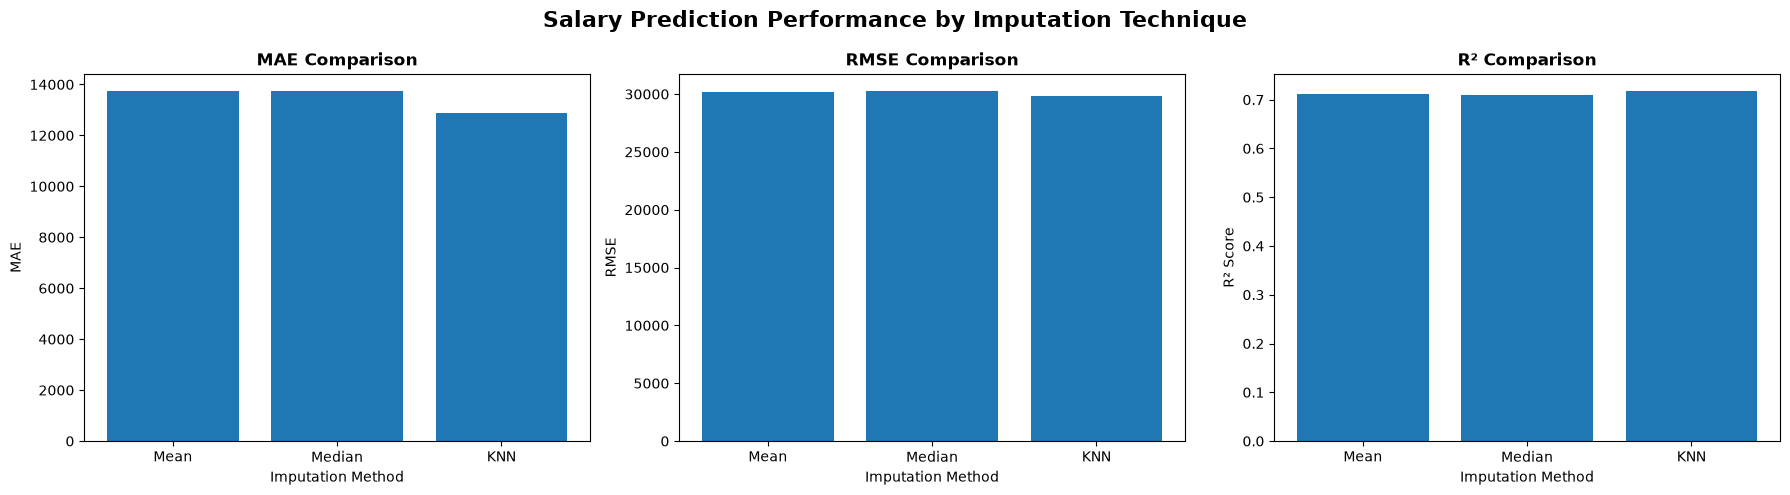

In [27]:
# STEP 5 - MODEL PERFORMANCE COMPARISON
# Mean vs Median vs KNN Imputation

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# 28. Load Imputed Datasets

mean_df = pd.read_csv("salary_mean_imputed.csv")
median_df = pd.read_csv("salary_median_imputed.csv")
knn_df = pd.read_csv("salary_knn_imputed.csv")


# 29. Target Variable
TARGET = "salary_bdt"
# 30. Function for Model Evaluation

def evaluate_model(data, method_name):

    # Separate features and target
    X = data.drop(columns=[TARGET])
    y = data[TARGET]

    # Identify categorical columns
    categorical_features = X.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    # Identify numerical columns
    numerical_features = X.select_dtypes(
        include=["number"]
    ).columns.tolist()

    # Preprocessing

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    
    # Model
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # Pipeline

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train-Test Split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    # Train Model

    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction

    y_pred = pipeline.predict(X_test)

    # Evaluation Metrics


    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    print("\nPerformance Results:")

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Imputation": method_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
# 31. Evaluate Mean Imputation
mean_result = evaluate_model(
    mean_df,
    "Mean"
)
# 32. Evaluate Median Imputation

median_result = evaluate_model(
    median_df,
    "Median"
)
# 33. Evaluate KNN Imputation
knn_result = evaluate_model(
    knn_df,
    "KNN"
)


# 34. Create Comparison DataFrame

results = pd.DataFrame([
    mean_result,
    median_result,
    knn_result
])


print(
    results.to_string(
        index=False
    )
)
# 35. Identify Best Methods

best_mae = results.loc[
    results["MAE"].idxmin()
]

best_rmse = results.loc[
    results["RMSE"].idxmin()
]

best_r2 = results.loc[
    results["R2"].idxmax()
]

print(
    f"\nBest MAE  : {best_mae['Imputation']}"
)

print(
    f"Best RMSE : {best_rmse['Imputation']}"
)

print(
    f"Best R²   : {best_r2['Imputation']}"
)


# 36. Save Performance Results
results.to_csv(
    "imputation_model_comparison.csv",
    index=False
)
# 37. Performance Comparison Chart

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# MAE
axes[0].bar(
    results["Imputation"],
    results["MAE"]
)

axes[0].set_title(
    "MAE Comparison",
    fontweight="bold"
)

axes[0].set_xlabel(
    "Imputation Method"
)

axes[0].set_ylabel(
    "MAE"
)

# RMSE
axes[1].bar(
    results["Imputation"],
    results["RMSE"]
)

axes[1].set_title(
    "RMSE Comparison",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Imputation Method"
)

axes[1].set_ylabel(
    "RMSE"
)

# R2
axes[2].bar(
    results["Imputation"],
    results["R2"]
)

axes[2].set_title(
    "R² Comparison",
    fontweight="bold"
)

axes[2].set_xlabel(
    "Imputation Method"
)

axes[2].set_ylabel(
    "R² Score"
)

plt.suptitle(
    "Salary Prediction Performance by Imputation Technique",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


In [30]:
# STEP 6 - FINAL ANALYSIS AND CONCLUSION

# 38. Display Final Comparison Table

final_results = results.copy()

final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["R2"] = final_results["R2"].round(4)

print(
    final_results.to_string(index=False)
)


# 39. Find Overall Best Method

best_mae_method = results.loc[
    results["MAE"].idxmin(),
    "Imputation"
]

best_rmse_method = results.loc[
    results["RMSE"].idxmin(),
    "Imputation"
]

best_r2_method = results.loc[
    results["R2"].idxmax(),
    "Imputation"
]


# 40. Overall Winner

method_scores = {
    "Mean": 0,
    "Median": 0,
    "KNN": 0
}

method_scores[best_mae_method] += 1
method_scores[best_rmse_method] += 1
method_scores[best_r2_method] += 1

overall_best = max(
    method_scores,
    key=method_scores.get
)


# 41. Calculate Improvement

mean_row = results[
    results["Imputation"] == "Mean"
].iloc[0]

best_row = results[
    results["Imputation"] == overall_best
].iloc[0]


mae_improvement = (
    (mean_row["MAE"] - best_row["MAE"])
    / mean_row["MAE"]
) * 100

rmse_improvement = (
    (mean_row["RMSE"] - best_row["RMSE"])
    / mean_row["RMSE"]
) * 100

r2_improvement = (
    best_row["R2"] - mean_row["R2"]
) * 100


# 42. Final Results

print(
    f"\nBest MAE Method  : {best_mae_method}"
)

print(
    f"Best RMSE Method : {best_rmse_method}"
)

print(
    f"Best R² Method   : {best_r2_method}"
)

print(
    f"\nOverall Best Method: {overall_best}"
)

print(
    f"\nMAE Improvement over Mean: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE Improvement over Mean: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"R² Improvement over Mean: "
    f"{r2_improvement:.2f} percentage points"
)

# 44. Save Final Results

final_results.to_csv(
    "task3_final_results.csv",
    index=False
)
print("\nFinal results saved as:")
print("task3_final_results.csv")


Imputation      MAE     RMSE     R2
      Mean 13729.00 30199.55 0.7107
    Median 13735.95 30250.36 0.7097
       KNN 12883.67 29846.14 0.7174

Best MAE Method  : KNN
Best RMSE Method : KNN
Best R² Method   : KNN

Overall Best Method: KNN

MAE Improvement over Mean: 6.16%
RMSE Improvement over Mean: 1.17%
R² Improvement over Mean: 0.67 percentage points

Final results saved as:
task3_final_results.csv
